   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/ee/deprecation.py:207: DeprecationWarning: 

Attention required for COPERNICUS/S2_SR! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR

  warnings.warn(warning, category=DeprecationWarning)


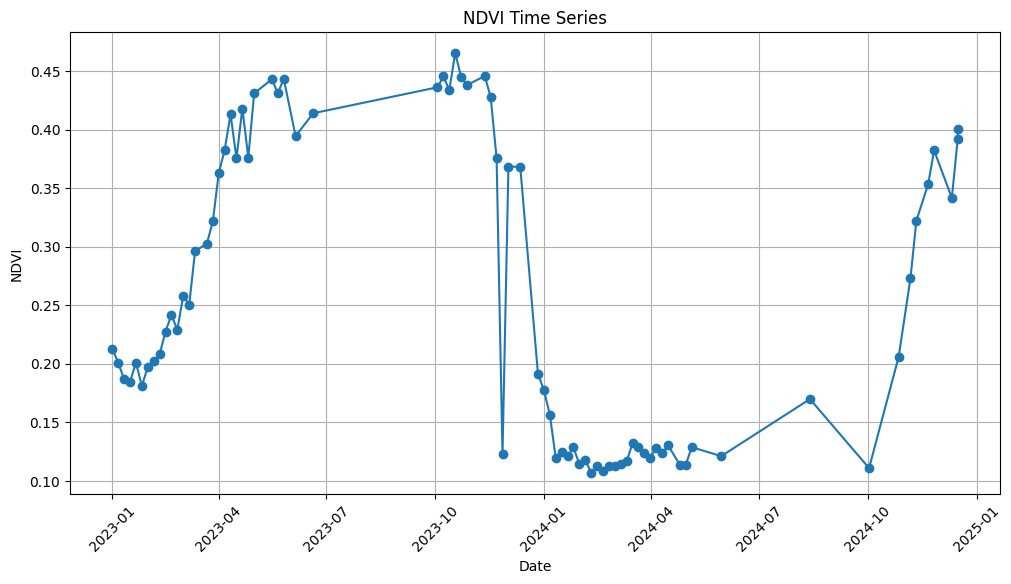

In [1]:
# Install libraries
!pip install earthengine-api geemap pandas matplotlib

# Import
import ee
import pandas as pd
import matplotlib.pyplot as plt

# Authenticate & Initialize
ee.Authenticate()
ee.Initialize(project='handy-post-458213-t7')

# -------------------------------
# 📍 Farm Boundary
# -------------------------------
roi = ee.Geometry.Polygon([
    [
        [75.619846, 16.287265],
        [75.61976, 16.287749],
        [75.623441, 16.287816],
        [75.623447, 16.287322],
        [75.619846, 16.287265]
    ]
])

# -------------------------------
# 🛰️ Load Sentinel-2 Collection
# -------------------------------
dataset = (ee.ImageCollection('COPERNICUS/S2_SR')
           .filterBounds(roi)
           .filterDate('2023-01-01', '2024-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

# -------------------------------
# 🌿 NDVI Function
# -------------------------------
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

ndvi_collection = dataset.map(addNDVI)

# -------------------------------
# 📊 Extract NDVI Values
# -------------------------------
def extract_ndvi(image):
    stats = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10
    )

    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM-dd'),
        'NDVI': stats.get('NDVI')
    })

ndvi_features = ndvi_collection.map(extract_ndvi)

# -------------------------------
# 📥 Convert to DataFrame
# -------------------------------
data = ndvi_features.getInfo()

dates = []
values = []

for feature in data['features']:
    dates.append(feature['properties']['date'])
    values.append(feature['properties']['NDVI'])

df = pd.DataFrame({
    'Date': dates,
    'NDVI': values
})

# Sort by date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# -------------------------------
# 📈 Plot NDVI Graph
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['NDVI'], marker='o')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('NDVI Time Series')
plt.grid()
plt.xticks(rotation=45)
plt.show()

